<a href="https://colab.research.google.com/github/eng20260311/AIFFEL_quest_eng/blob/master/NLP/NLP03/chatbot_transformer_rag_final_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 한국어 챗봇 — Transformer + 데이터 증강 + RAG 평가

ChatbotData(약 1.1만 개 질문-답변 쌍)로 한국어 챗봇을 만드는 노트북입니다. 작은 데이터셋의 한계를 극복하기 위해 **세 가지 데이터 증강 전략**을 결합하고, **SBERT 기반 RAG retrieval**과 성능을 비교 평가합니다.

## 전체 파이프라인

| 단계 | 내용 |
|---|---|
| Step 0 | Mecab(은전한닢) + 필수 라이브러리 설치 |
| Step 1 | songys/Chatbot_data CSV 다운로드 |
| Step 2 | `preprocess_sentence` — 한글/영문/숫자/주요 부호만 유지 |
| Step 3 | `build_corpus` — Mecab 형태소 분석 + 길이 필터 + 중복 제거 |
| **Step 4** | **데이터 증강 (3종)** |
| 4-1 | 단순 EDA — 토큰 랜덤 삭제/스왑 |
| 4-2 | SBERT 유사 질문 매칭 — 의미 비슷한 Q끼리 A 교차 |
| 4-3 | Back-Translation — ko→en→ko 역번역 |
| Step 5 | `<start>`/`<end>` 추가, 공유 단어사전, 패딩 |
| **Step 6** | **Transformer 학습 + 학습 손실 그래프** |
| Step 7 | BLEU 평가 + SBERT RAG 챗봇과 비교 |

## 두 챗봇을 함께 평가하는 이유

- **Transformer 챗봇 (생성형)**: 학습 데이터를 일반화해 새로운 답변을 만들어냄. 데이터가 적으면 어색해지기 쉬움.
- **RAG 챗봇 (검색형)**: 학습한 KB에서 가장 비슷한 질문을 찾아 그 답변을 가져옴. 코퍼스 안에 정답이 있으면 자연스러움.

같은 평가 셋에서 BLEU를 비교하면 두 접근법의 장단점이 분명히 드러납니다.

## 실행 환경

- **Colab GPU 권장** (Mecab/SBERT/Back-Translation 합쳐서 GPU 없으면 시간이 오래 걸림)
- 위에서부터 차례대로 실행하면 동작합니다.


## Step 0. 환경 설정

Colab에 mecab(은전한닢)과 필요한 라이브러리를 설치합니다.

In [ ]:
# Mecab(한국어 형태소 분석기) 설치
# - konlpy 자체는 pip로 받지만, 내부적으로 사용하는 mecab-ko 바이너리는
#   별도 셸 스크립트로 설치해야 함
# - 약 1~2분 소요. 다른 환경(Kaggle/로컬)이면 'python-mecab-ko'를 사용 권장:
#       !pip install python-mecab-ko
#       from mecab import MeCab; mecab = MeCab()
!pip install -q konlpy
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 17.5 MB/s eta 0:00:00
Install mecab-ko
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1381k  100 1381k    0     0   919k      0  0:00:01  0:00:01 --:--:-- 5172k
mecab-0.996-ko-0.9.2/
mecab-0.996-ko-0.9.2/example/
mecab-0.996-ko-0.9.2/example/example.cpp
mecab-0.996-ko-0.9.2/example/example_lattice.cpp
mecab-0.996-ko-0.9.2/example/example_lattice.c
mecab-0.996-ko-0.9.2/example/example.c
mecab-0.996-ko-0.9.2/example/thread_test.cpp
mecab-0.996-ko-0.9.2/mecab-config.in
mecab-0.996-ko-0.9.2/man/
mecab-0.996-ko-0.9.2/man/Makefile.am
mecab-0.996-ko-0.9.2/man/mecab.1
mecab-0.996-ko-0.9.2/man/Makefile.in
mecab-0.996-ko-0.9.2/mecab.iss.in
mecab-0.996-ko-0.9.2/config.gu

In [ ]:
# 그 외 필요 라이브러리
# - gensim    : (사용 안 함, 호환성 차원에서 유지)
# - sentencepiece : transformers의 토크나이저 의존
# - nltk      : BLEU 계산용
# - tqdm      : 진행률 표시
!pip install -q gensim sentencepiece nltk tqdm
!pip install python-mecab-ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 49.5 MB/s eta 0:00:00


In [ ]:
# 공통 import. 이후 모든 셀에서 공유됨
import os, re, random, math, time, urllib.request, io, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm

# 디바이스 자동 선택 (GPU 우선)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# 재현성을 위한 시드 고정 (완전한 재현은 아니지만 비슷한 결과 유도)
torch.manual_seed(42); random.seed(42); np.random.seed(42)


device: cuda


## Step 1. 데이터 다운로드

`songys/Chatbot_data`의 `ChatbotData.csv`를 사용합니다.

In [ ]:
import pandas as pd

URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
df = pd.read_csv(URL)
print("총 페어 수:", len(df))
df.head()


총 페어 수: 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [ ]:
questions = df["Q"].tolist()
answers   = df["A"].tolist()
print(len(questions), len(answers))
print(questions[:3])
print(answers[:3])


11823 11823
['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다']
['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.']


## Step 2. `preprocess_sentence`

- 영문자는 소문자로 변환
- 한글, 영문, 숫자, 주요 특수문자(`.?!,`)만 남기고 제거
- 토크나이저(mecab)가 구두점 분리를 알아서 해주므로 따로 공백 패딩은 하지 않음


In [ ]:
def preprocess_sentence(sentence):
    """문장 단위 정제.

    - 영문은 소문자로 통일 (대소문자 구분이 챗봇 의미 차이를 만들지 않음)
    - 한글, 영문, 숫자, 주요 부호(? . ! ,)만 남기고 나머지는 공백 처리
    - 연속 공백 압축

    문장 부호 양옆 공백 분리는 별도 처리하지 않음 — Mecab이 알아서 분리함.
    """
    sentence = sentence.lower()                                # 1) 소문자화
    sentence = re.sub(r"[^a-z0-9가-힣?.!,]+", " ", sentence)   # 2) 허용 외 제거
    sentence = re.sub(r"\s+", " ", sentence).strip()          # 3) 공백 정리
    return sentence


# 동작 확인
print(preprocess_sentence("안녕하세요!! 오늘 너~~무 신난다 ^_^ 123"))
print(preprocess_sentence("Hello, World!! 반가워요 :)"))


안녕하세요!! 오늘 너 무 신난다 123
hello, world!! 반가워요


## Step 3. `build_corpus` (Mecab 토큰화)

- 입력: 소스/타깃 리스트, 토크나이즈 함수(`mecab.morphs`)
- `preprocess_sentence`로 정제 후 토큰화
- 일정 길이 이상 토큰은 제외
- **중복은 소스/타깃 각각 따로 검사** — 쌍이 깨지면 안 되므로 인덱스 단위로 처리


In [ ]:
from mecab import MeCab   # konlpy가 아니라 python-mecab-ko의 MeCab
mecab = MeCab()
print(mecab.morphs("간만에 여자친구랑 데이트 하기로 했어"))


['간만에', '여자', '친구', '랑', '데이트', '하', '기', '로', '했', '어']


In [ ]:
def build_corpus(src_list, tgt_list, tokenize_fn, max_len=30):
    """병렬 코퍼스 구축.

    Parameters
    ----------
    src_list, tgt_list : list[str]
        같은 길이의 병렬 원문 리스트. (질문, 답변)
    tokenize_fn : callable
        문자열을 토큰 리스트로 바꾸는 함수. 예) mecab.morphs
    max_len : int
        토큰 수가 이 값을 넘는 페어는 학습에서 제외 (메모리/속도 절약).

    Returns
    -------
    (src_corpus, tgt_corpus) : tuple[list[list[str]], list[list[str]]]
        토큰화된 병렬 코퍼스. 둘의 길이는 같음.

    중복 처리
    --------
    소스/타깃 **각각** 따로 중복 검사. 쌍이 꼬이지 않도록 인덱스 단위로 처리.
    같은 질문이 두 번 나오면 두 번째 페어는 제외 (답변이 다르더라도).
    """
    assert len(src_list) == len(tgt_list)

    seen_src = set()
    seen_tgt = set()
    src_corpus, tgt_corpus = [], []

    for s, t in zip(src_list, tgt_list):
        s_clean = preprocess_sentence(s)
        t_clean = preprocess_sentence(t)

        # 어느 한 쪽이라도 중복이면 페어 전체를 버림 (정렬을 흐트러뜨리지 않음)
        if s_clean in seen_src or t_clean in seen_tgt:
            continue

        s_tok = tokenize_fn(s_clean)
        t_tok = tokenize_fn(t_clean)

        # 빈 문장이나 너무 긴 문장 제외
        if len(s_tok) == 0 or len(t_tok) == 0:
            continue
        if len(s_tok) > max_len or len(t_tok) > max_len:
            continue

        seen_src.add(s_clean)
        seen_tgt.add(t_clean)
        src_corpus.append(s_tok)
        tgt_corpus.append(t_tok)

    return src_corpus, tgt_corpus


# 챗봇 코퍼스에 적용
que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_len=30)
print("페어 수:", len(que_corpus))
print("샘플:", que_corpus[0], "->", ans_corpus[0])


페어 수: 7730
샘플: ['12', '시', '땡', '!'] -> ['하루', '가', '또', '가', '네요', '.']


## Step 4. Augmentation (SBERT 기반)

**SBERT 한국어 모델** (`jhgan/ko-sroberta-multitask`, ~400MB)을 사용한 새로운 증강 전략:

1. **단순 EDA**: 랜덤 토큰 삭제/스왑 (외부 모델 불필요, 빠름)
2. **유사 질문 매칭**: SBERT로 의미가 비슷한 질문 페어를 찾아 답변을 교차 매칭
   → 같은 의미의 다양한 표현에 같은 답변을 학습 → 일반화 강화
3. **Back-Translation**: ko→en→ko 역번역으로 자연스러운 표현 다양화

또한 SBERT는 **Step 7의 RAG retrieval**에서도 활용해 검색 품질을 크게 끌어올립니다.

> 변경 이력: Kyubyong/wordvectors(ko.bin) → FastText cc.ko.300 → SBERT
> SBERT는 단어가 아닌 문장 단위 임베딩이라 단어 치환 EDA는 다른 방식(랜덤 삭제/스왑)으로 대체합니다.


In [ ]:
# SBERT 한국어 모델 로드
# - jhgan/ko-sroberta-multitask: 한국어 SBERT, 약 400MB
# - 문장을 768차원 벡터로 변환. 의미가 비슷한 문장끼리 cosine 유사도가 높음
# - 두 가지 용도로 사용:
#   1) Step 4-2: 데이터 증강 (유사 질문 페어 발굴 후 답변 교차 매칭)
#   2) Step 7  : RAG 챗봇의 검색 인덱스
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer

print("SBERT 모델 로드 중... (첫 실행 시 약 400MB 다운로드)")
sbert = SentenceTransformer("jhgan/ko-sroberta-multitask")
sbert = sbert.to(device)
print("로드 완료. 임베딩 차원:", sbert.get_sentence_embedding_dimension())

# 동작 확인 — 의미가 비슷한 두 문장의 유사도가 0.7 이상이면 OK
test = ["오늘 너무 피곤해", "지친다 정말", "행복한 하루였어"]
emb = sbert.encode(test, convert_to_tensor=True, normalize_embeddings=True)
sim = (emb @ emb.T).cpu().numpy()
print("\n유사도 매트릭스:")
for i, s in enumerate(test):
    for j, t in enumerate(test):
        if i < j:
            print(f"  '{s}' vs '{t}': {sim[i,j]:.3f}")


SBERT 모델 로드 중... (첫 실행 시 약 400MB 다운로드)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_1230/3842242979.py:14: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("로드 완료. 임베딩 차원:", sbert.get_sentence_embedding_dimension())


로드 완료. 임베딩 차원: 768

유사도 매트릭스:
  '오늘 너무 피곤해' vs '지친다 정말': 0.711
  '오늘 너무 피곤해' vs '행복한 하루였어': 0.373
  '지친다 정말' vs '행복한 하루였어': 0.267


In [ ]:
import random


def simple_eda(tokens, p_delete=0.1, p_swap=0.1, min_len=2):
    """Word2Vec 없는 단순 EDA.

    - Random Deletion: 각 토큰을 p_delete 확률로 삭제
    - Random Swap   : p_swap 확률로 인접 두 토큰의 자리 바꿈
    - 결과가 너무 짧아지면(min_len 미만) 원본 복구

    의미를 크게 해치지 않으면서 모델이 표현 변동에 강건해지도록 돕습니다.
    질문(que)에만 적용하고 답변은 그대로 유지하는 게 안전합니다.
    """
    new = list(tokens)
    if len(new) <= min_len:
        return new

    # 1) Random Deletion
    new = [t for t in new if random.random() > p_delete]
    if len(new) < min_len:
        new = list(tokens)

    # 2) Random Swap (인접 한 쌍만)
    if random.random() < p_swap and len(new) > 1:
        i = random.randint(0, len(new) - 2)
        new[i], new[i+1] = new[i+1], new[i]

    return new


# 데모
sample = ["지루", "하", "다", "놀러", "가", "고", "싶", "어"]
print("원본:", sample)
for i in range(3):
    print(f"EDA{i+1}:", simple_eda(sample))


원본: ['지루', '하', '다', '놀러', '가', '고', '싶', '어']
EDA1: ['지루', '다', '놀러', '가', '고', '싶']
EDA2: ['하', '다', '가', '고', '싶', '어']
EDA3: ['다', '지루', '놀러', '가', '고', '싶', '어']


In [ ]:
# === 1단계 증강: 단순 EDA ===
# 원본 질문에 랜덤 삭제/스왑을 적용해 추가 페어 생성. 답변은 원본 그대로.
print("=== 1단계: 단순 EDA ===")
eda_aug_que = []
eda_aug_ans = []
for q, a in zip(que_corpus, ans_corpus):
    aug_q = simple_eda(q, p_delete=0.1, p_swap=0.1)
    if aug_q != q:  # 변화가 있을 때만 추가 (의미 없는 중복 방지)
        eda_aug_que.append(aug_q)
        eda_aug_ans.append(list(a))
print(f"단순 EDA로 추가된 페어: {len(eda_aug_que)}")


# === 2단계 준비: SBERT 임베딩 ===
# 모든 원본 질문을 SBERT로 임베딩. 다음 셀에서 유사 질문 매칭에 사용.
# normalize_embeddings=True로 단위 벡터화 → 내적이 곧 cosine 유사도가 됨.
print("\n=== 2단계 준비: SBERT 임베딩 ===")
print("모든 질문을 SBERT로 임베딩 중...")
question_texts = [" ".join(q) for q in que_corpus]
q_embeddings = sbert.encode(
    question_texts,
    convert_to_tensor=True,
    show_progress_bar=True,
    batch_size=64,
    normalize_embeddings=True,
)
print(f"임베딩 shape: {q_embeddings.shape}")


=== 1단계: 단순 EDA ===
단순 EDA로 추가된 페어: 4262

=== 2단계 준비: SBERT 임베딩 ===
모든 질문을 SBERT로 임베딩 중...


Batches:   0%|          | 0/121 [00:00<?, ?it/s]

임베딩 shape: torch.Size([7730, 768])


### 4-2. SBERT 유사 질문 매칭 증강

의미적으로 비슷한 질문들을 찾아 답변을 교차 매칭합니다.

- 예: "심심해" 와 "지루하다" 가 SBERT 유사도 0.85라면
  - (심심해, 지루하다의 답) 페어 추가
  - (지루하다, 심심해의 답) 페어 추가
- 같은 의미의 다양한 표현에 같은 답변을 학습 → 모델 일반화 ↑
- 답변은 **원본 그대로 사용** → 자연스러움 보존


In [ ]:
import torch
from tqdm.notebook import tqdm


def similar_question_augment(que_corpus, ans_corpus, q_embeddings,
                              sim_threshold=0.75, max_pairs_per_q=2):
    """SBERT 임베딩 기반 유사 질문 매칭 증강.

    의미가 비슷한 (Q1, Q2) 쌍을 찾아 답변을 교차 매칭.
    예: "심심해"와 "지루하다"가 유사도 0.85라면
        → (심심해, 지루하다의 답변) 페어 추가
        → 모델이 같은 의미의 다양한 표현에 같은 의도로 반응하도록 학습

    Parameters
    ----------
    sim_threshold : float
        이 값 이상 유사한 쌍만 사용. 보수적으로 0.80 권장.
        너무 낮추면(0.70~) 의미 다른 페어가 섞이고,
        너무 높이면(0.90~) 거의 동일한 쌍만 잡혀 다양성이 안 늚.
    max_pairs_per_q : int
        한 질문당 매칭할 최대 유사 질문 수.
    """
    add_que = []
    add_ans = []
    N = q_embeddings.size(0)

    # 메모리 절약을 위해 배치 단위로 (N x N) 유사도 매트릭스 계산
    BATCH = 256
    for start in tqdm(range(0, N, BATCH), desc="유사 질문 매칭"):
        end = min(start + BATCH, N)
        sims = q_embeddings[start:end] @ q_embeddings.T   # (BATCH, N) cosine

        # 자기 자신과의 유사도는 항상 1이므로 제외
        for local_i in range(end - start):
            global_i = start + local_i
            sims[local_i, global_i] = -1.0

        # top-k 유사 질문 추출
        top_vals, top_idxs = torch.topk(sims, k=max_pairs_per_q, dim=1)

        for local_i in range(end - start):
            global_i = start + local_i
            for k in range(max_pairs_per_q):
                sim_val = top_vals[local_i, k].item()
                if sim_val < sim_threshold:
                    continue
                j = top_idxs[local_i, k].item()
                # (Q_i 질문, A_j 답변) 페어 추가
                add_que.append(list(que_corpus[global_i]))
                add_ans.append(list(ans_corpus[j]))

    return add_que, add_ans


sim_aug_que, sim_aug_ans = similar_question_augment(
    que_corpus, ans_corpus, q_embeddings,
    sim_threshold=0.80,   # 보수적 설정
    max_pairs_per_q=1,    # 한 질문당 1개씩만 매칭
)
print(f"\nSBERT 유사 질문 매칭으로 추가된 페어: {len(sim_aug_que)}")

# 샘플 확인
print("\n샘플 매칭 결과:")
for i in range(min(5, len(sim_aug_que))):
    print(f"  Q: {' '.join(sim_aug_que[i])}")
    print(f"  A: {' '.join(sim_aug_ans[i])}\n")


유사 질문 매칭:   0%|          | 0/31 [00:00<?, ?it/s]


SBERT 유사 질문 매칭으로 추가된 페어: 2980

샘플 매칭 결과:
  Q: 가끔 궁금 해
  A: 궁금 할 수 있 어요 .

  Q: 가끔 은 혼자 인 게 좋 다
  A: 혼자 만 있 지 마세요 .

  Q: 가족 여행 가 기 로 했 어
  A: 좋 은 생각 이 에요 .

  Q: 가족 끼리 여행 간다 .
  A: 좋 은 생각 이 에요 .

  Q: 가족 들 이랑 여행 갈 거 야
  A: 더 가까워질 기회 가 되 겠 네요 .



In [ ]:
# 1단계 + 2단계 증강을 원본 코퍼스에 합쳐 src_corpus/tgt_corpus 생성
# (3단계 Back-Translation은 다음 섹션에서 별도 추가)

src_corpus = list(que_corpus) + eda_aug_que + sim_aug_que
tgt_corpus = list(ans_corpus) + eda_aug_ans + sim_aug_ans

assert len(src_corpus) == len(tgt_corpus)
print(f"원본          : {len(que_corpus)}")
print(f"+ 단순 EDA    : +{len(eda_aug_que)}")
print(f"+ 유사 질문   : +{len(sim_aug_que)}")
print(f"합계          : {len(src_corpus)}  (원본 대비 {len(src_corpus)/len(que_corpus):.2f}배)")


원본          : 7730
+ 단순 EDA    : +4262
+ 유사 질문   : +2980
합계          : 14972  (원본 대비 1.94배)


### 4-3. Back-Translation (역번역)

질문을 영어로 번역했다가 다시 한국어로 번역하면, **의미는 유지되면서 표현이 자연스럽게 바뀝니다**.

```
"지루하다 놀러가고 싶어"
  → "I'm bored, I want to go play"
  → "심심해, 나가서 놀고 싶어"
```

- 사용 모델: Helsinki-NLP의 opus-mt (ko↔en)
- **질문에만 적용** — 답변은 자연스러움이 핵심이라 보존
- 시간 절약을 위해 `MAX_BT_SAMPLES`로 상한 설정

> 참고: `transformers` 일부 버전에서 `pipeline("translation")` 호출에 버그가 있어,
> 모델과 토크나이저를 직접 로드하는 방식으로 구현했습니다.


In [ ]:
# Hugging Face transformers와 토크나이저 의존성 설치
!pip install -q transformers sentencepiece


In [ ]:
# 번역 모델 직접 로드
# - pipeline() 호출은 transformers 일부 버전에서 KeyError 발생
# - AutoTokenizer + AutoModelForSeq2SeqLM 조합이 안정적
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("ko→en 모델 로드 중...")
ko2en_tok = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-ko-en")
ko2en_model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-ko-en").to(dev)
ko2en_model.eval()

print("en→ko 모델 로드 중...")
en2ko_tok = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-tc-big-en-ko")
en2ko_model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-tc-big-en-ko").to(dev)
en2ko_model.eval()


def translate(texts, tokenizer, model, max_length=128, num_beams=2):
    """단일 방향 번역. texts: str 또는 list[str] → list[str]"""
    if isinstance(texts, str):
        texts = [texts]
    inputs = tokenizer(texts, return_tensors="pt", padding=True,
                       truncation=True, max_length=max_length).to(dev)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=max_length, num_beams=num_beams)
    return tokenizer.batch_decode(outputs, skip_special_tokens=True)


# 데모
test_sentences = ["지루하다 놀러가고 싶어", "오늘 일찍 일어났더니 피곤하다"]
en_results = translate(test_sentences, ko2en_tok, ko2en_model)
bt_results = translate(en_results, en2ko_tok, en2ko_model)
for s, e, b in zip(test_sentences, en_results, bt_results):
    print(f"원문 : {s}")
    print(f"  EN : {e}")
    print(f"  BT : {b}\n")


ko→en 모델 로드 중...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/418M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

원문 : 지루하다 놀러가고 싶어
  EN : I'm bored. I want to go out for fun.
  BT : US호텔 8층. US카운팅 하트베어링로드 #컨버전스.

원문 : 오늘 일찍 일어났더니 피곤하다
  EN : I woke up early today and I'm tired.
  BT : US 부여 US 호텔 8 종료합니다.



In [ ]:
def back_translate_batch(texts, batch_size=32, max_length=128):
    """배치로 ko→en→ko 역번역.

    texts: 문자열 리스트
    → 같은 길이의 역번역된 문자열 리스트 반환
    """
    # ko → en (배치 처리)
    en_results = []
    for i in range(0, len(texts), batch_size):
        en_results.extend(translate(texts[i:i+batch_size], ko2en_tok, ko2en_model, max_length))
    # en → ko (배치 처리)
    bt_results = []
    for i in range(0, len(en_results), batch_size):
        bt_results.extend(translate(en_results[i:i+batch_size], en2ko_tok, en2ko_model, max_length))
    return bt_results


# Back-Translation 적용 — 시간 절약을 위해 상한선 설정
# 전체 질문에 적용하고 싶으면 MAX_BT_SAMPLES = len(que_corpus)
MAX_BT_SAMPLES = 3000

# 원문 복원 (que_corpus는 이미 토큰 리스트라 join으로 복원)
sample_indices = random.sample(range(len(que_corpus)), min(MAX_BT_SAMPLES, len(que_corpus)))
sample_texts = [" ".join(que_corpus[i]) for i in sample_indices]

print(f"Back-Translation 적용 대상: {len(sample_texts)}개")
bt_texts = back_translate_batch(sample_texts, batch_size=32)

# 역번역 결과를 다시 토큰화하고 페어로 추가
# - 토큰 수가 정상 범위(1~30)
# - 원본과 정확히 동일하면 의미 없으므로 제외
bt_src_extra = []
bt_tgt_extra = []
for orig_idx, bt_text in zip(sample_indices, bt_texts):
    bt_tokens = mecab.morphs(preprocess_sentence(bt_text))
    if 1 <= len(bt_tokens) <= 30 and bt_tokens != que_corpus[orig_idx]:
        bt_src_extra.append(bt_tokens)
        bt_tgt_extra.append(list(ans_corpus[orig_idx]))

print(f"Back-Translation으로 추가된 페어 수: {len(bt_src_extra)}")
print("\n샘플:")
for i in range(min(3, len(bt_src_extra))):
    print(f"  원본: {' '.join(que_corpus[sample_indices[i]])}")
    print(f"  BT  : {' '.join(bt_src_extra[i])}")
    print(f"  답변: {' '.join(bt_tgt_extra[i])}\n")


Back-Translation 적용 대상: 3000개
Back-Translation으로 추가된 페어 수: 2962

샘플:
  원본: 내 가 진짜 즐길 수 있 을 게 뭘까
  BT  : us 9001 hotel 에서 독점 적 으로 미국 유사성 .
  답변: 할 일 이 많 은데 안 하 는 것 이 요 .

  원본: 나 사랑 에 빠졌 죠
  BT  : 92 에 의해
  답변: 행복 해보여요 .

  원본: 웹툰 뭐 볼까
  BT  : excel 호텔 kinook 부정 행위 주 chinese 명예
  답변: 안 본 웹툰 이 있 는지 먼저 물 어 보 고 싶 네요 .



### 4-4. 최종 증강 데이터 통합

- 원본 (que, ans)
- 기존 lexical_sub 증강
- EDA 증강 (질문만)
- Back-Translation 증강 (질문만)

답변은 자연스러움 보존을 위해 토큰 단위 증강 없이, **다른 표현의 질문에 같은 답변**을 매칭하는 방식으로만 다양화합니다.

In [ ]:
# 이전 단계까지의 src_corpus / tgt_corpus 에 Back-Translation 결과를 추가
before = len(src_corpus)
src_corpus = list(src_corpus) + bt_src_extra
tgt_corpus = list(tgt_corpus) + bt_tgt_extra

assert len(src_corpus) == len(tgt_corpus)

print(f"증강 전           : {before}")
print(f"+ Back-Translation: +{len(bt_src_extra)}")
print(f"최종 페어 수      : {len(src_corpus)}  (원본 대비 {len(src_corpus)/len(que_corpus):.2f}배)")

# 메모리 정리 — 번역 모델 해제
# SBERT는 RAG에서 또 쓰므로 유지
# 변수가 없어도 에러 안 나도록 globals() 체크
for name in ["ko2en_tok", "ko2en_model", "en2ko_tok", "en2ko_model", "ko2en", "en2ko"]:
    if name in globals():
        del globals()[name]
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


증강 전           : 14972
+ Back-Translation: +2962
최종 페어 수      : 17934  (원본 대비 2.32배)


## Step 5. 벡터화

학습에 쓰일 형태로 데이터를 준비합니다.

1. 타깃 답변에 `<start>` / `<end>` 토큰 추가
   → Transformer 디코더는 `<start>`를 보고 답을 시작, `<end>`를 만나면 종료
2. **공유 단어사전** 구축
   → 챗봇은 소스(질문)와 타깃(답변)이 같은 언어이므로 사전 공유 가능
   → 임베딩 가중치 공유로 파라미터 수 감소 + 일반화 향상
3. 가변 길이 시퀀스를 패딩하여 `(batch, max_len)` 텐서로 변환


In [ ]:
# 답변에 <start>/<end> 토큰 추가
# - <start>: 디코더가 첫 토큰을 생성할 때 입력으로 사용
# - <end>  : 모델이 답변 끝을 표시하도록 학습
tgt_corpus = [["<start>"] + a + ["<end>"] for a in tgt_corpus]
print(tgt_corpus[0])


['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']


In [ ]:
# 공유 단어사전 구축
# - <pad>(0): 패딩용. padding_idx로 임베딩에서 항상 0 벡터 유지
# - <unk>(1): 사전에 없는 단어
# - <start>(2), <end>(3): 답변 시퀀스 경계
# - 그 외: 빈도 순으로 정렬해 추가
PAD, UNK, START, END = "<pad>", "<unk>", "<start>", "<end>"
specials = [PAD, UNK, START, END]

from collections import Counter
counter = Counter()
for s in src_corpus: counter.update(s)
for t in tgt_corpus: counter.update(t)

# specials 먼저, 그 다음 빈도순으로 vocab 구성
vocab = list(specials) + [w for w, _ in counter.most_common() if w not in specials]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(vocab)
print("공유 사전 크기:", VOCAB_SIZE)


공유 사전 크기: 7742


In [ ]:
# 토큰 → ID 변환 + 배치 내 최대 길이로 패딩
def encode(tokens):
    """토큰 리스트를 ID 리스트로 변환. 미등록 단어는 <unk>."""
    return [word2idx.get(t, word2idx[UNK]) for t in tokens]


src_ids = [encode(s) for s in src_corpus]
tgt_ids = [encode(t) for t in tgt_corpus]


def pad(seqs, pad_id=0):
    """가변 길이 시퀀스 리스트를 (N, max_len) 텐서로 패딩."""
    seqs = [torch.tensor(s, dtype=torch.long) for s in seqs]
    return torch.nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=pad_id)


enc_train = pad(src_ids, pad_id=word2idx[PAD])
dec_train = pad(tgt_ids, pad_id=word2idx[PAD])
print("enc_train:", enc_train.shape)
print("dec_train:", dec_train.shape)


enc_train: torch.Size([17934, 29])
dec_train: torch.Size([17934, 32])


## Step 6. Transformer 학습

Transformer 인코더-디코더 구조를 처음부터 구현합니다.

- **인코더**: 질문 토큰들 사이의 관계를 self-attention으로 파악해 context 벡터 생성
- **디코더**: 인코더의 context를 참조하면서(`cross-attention`), 자기가 만든 토큰들도 self-attention으로 보면서(`masked self-attention`), 한 토큰씩 답변 생성
- **Weight tying**: 디코더 임베딩과 출력 projection을 공유 → 파라미터 수 감소, 일반화 향상 (특히 사전이 공유될 때 효과적)
- **Pre-LN 구조**: 각 sublayer 진입 전에 LayerNorm 적용 → Post-LN보다 학습 안정성 ↑

### 학습 설정

- 옵티마이저: Adam (β₁=0.9, β₂=0.98, ε=1e-9 — 논문 권장)
- 학습률 스케줄: warmup → step^(-0.5) 감쇠 (논문 방식)
- 손실: `<pad>` 위치를 제외한 cross-entropy


In [ ]:
# ===== Multi-Head Self-Attention =====
# Transformer의 핵심 블록. Query/Key/Value를 여러 헤드로 분할해
# 서로 다른 표현 공간에서 동시에 attention을 계산함.

class MultiHeadAttention(nn.Module):
    """Multi-Head Scaled Dot-Product Attention.

    forward(Q, K, V, mask) → (출력, attention 가중치)
    - mask=1 위치는 attention에서 차단 (-inf로 마스킹 후 softmax)
    """

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 함"
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads  # 각 헤드의 차원
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)  # 헤드 concat 후 projection

    def split_heads(self, x):
        """(B, S, d_model) → (B, num_heads, S, depth)"""
        b, s, _ = x.shape
        return x.view(b, s, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        """(B, num_heads, S, depth) → (B, S, d_model)"""
        b, h, s, d = x.shape
        return x.permute(0, 2, 1, 3).contiguous().view(b, s, self.d_model)

    def attn(self, Q, K, V, mask):
        """Scaled Dot-Product Attention."""
        d_k = K.shape[-1]
        qk = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            qk = qk.masked_fill(mask == 1, float("-1e9"))  # 마스크=1을 차단
        w = F.softmax(qk, dim=-1)
        return torch.matmul(w, V), w

    def forward(self, Q, K, V, mask=None):
        # 1) Q, K, V 선형 변환 후 헤드 분할
        Qh = self.split_heads(self.W_q(Q))
        Kh = self.split_heads(self.W_k(K))
        Vh = self.split_heads(self.W_v(V))
        # 2) 헤드별로 attention 계산
        out, w = self.attn(Qh, Kh, Vh, mask)
        # 3) 헤드 합치고 최종 projection
        return self.linear(self.combine_heads(out)), w


class PoswiseFFN(nn.Module):
    """Position-wise Feed-Forward Network.

    각 위치(토큰)별로 동일하게 적용되는 2층 MLP.
    채널 차원을 d_ff(보통 d_model의 4배)로 확장했다가 다시 축소.
    """

    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


In [ ]:
class EncoderLayer(nn.Module):
    """Transformer 인코더 한 층 (Pre-LN 구조).

    구성: Self-Attention → Add → FFN → Add
    각 sublayer 진입 전에 LayerNorm. residual은 정규화 전 값에 합산.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFFN(d_model, d_ff)
        self.n1 = nn.LayerNorm(d_model, eps=1e-6)
        self.n2 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Pre-LN: LayerNorm을 sublayer 입력에 적용
        r = x; x = self.n1(x); x, _ = self.attn(x, x, x, mask); x = self.drop(x) + r
        r = x; x = self.n2(x); x = self.ffn(x);                 x = self.drop(x) + r
        return x


class DecoderLayer(nn.Module):
    """Transformer 디코더 한 층 (Pre-LN 구조).

    구성: Masked Self-Attention → Cross-Attention(enc_out) → FFN
    - Masked Self-Attention: 미래 토큰을 보지 못하도록 causal mask 적용
    - Cross-Attention: Query=디코더 출력, Key/Value=인코더 출력
                       → 답변 생성 중 질문의 어디를 볼지 학습
    """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFFN(d_model, d_ff)
        self.n1 = nn.LayerNorm(d_model, eps=1e-6)
        self.n2 = nn.LayerNorm(d_model, eps=1e-6)
        self.n3 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, enc_out, self_mask, cross_mask):
        r = x; x = self.n1(x); x, _ = self.self_attn(x, x, x, self_mask);              x = self.drop(x) + r
        r = x; x = self.n2(x); x, _ = self.cross_attn(x, enc_out, enc_out, cross_mask); x = self.drop(x) + r
        r = x; x = self.n3(x); x = self.ffn(x);                                         x = self.drop(x) + r
        return x


def positional_encoding(pos, d_model):
    """Sinusoidal Positional Encoding.

    학습되지 않는 고정 임베딩. 짝수 차원에 sin, 홀수에 cos를 사용해
    임의 위치 간의 상대적 거리를 모델이 학습할 수 있게 함.
    """
    angle = np.array([[p / np.power(10000, 2 * (i // 2) / d_model) for i in range(d_model)] for p in range(pos)])
    angle[:, 0::2] = np.sin(angle[:, 0::2])
    angle[:, 1::2] = np.cos(angle[:, 1::2])
    return torch.FloatTensor(angle)


class Transformer(nn.Module):
    """전체 인코더-디코더 Transformer (챗봇 버전, weight tying 적용)."""

    def __init__(self, vocab_size, n_layers=2, d_model=256, n_heads=8, d_ff=1024,
                 pos_len=128, dropout=0.2, shared_emb=True):
        super().__init__()
        self.d_model = d_model
        self.shared_emb = shared_emb

        # 임베딩: shared_emb=True면 인코더/디코더가 같은 임베딩 사용
        # 챗봇은 소스/타깃이 같은 언어라 공유 효과가 큼
        self.enc_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.dec_emb = nn.Embedding(vocab_size, d_model, padding_idx=0) if not shared_emb else self.enc_emb

        # 미리 계산된 positional encoding (학습 안 됨, register_buffer로 저장)
        self.register_buffer("pe", positional_encoding(pos_len, d_model))
        self.drop = nn.Dropout(dropout)

        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

        # 최종 vocab projection. 디코더 임베딩과 weight tying.
        self.fc = nn.Linear(d_model, vocab_size)
        self.fc.weight = self.dec_emb.weight

    def embed(self, emb, x):
        """토큰 ID → 임베딩 + Positional Encoding + Dropout"""
        out = emb(x) * math.sqrt(self.d_model)  # 임베딩 스케일링 (논문 권장)
        out = out + self.pe[:x.size(1)].unsqueeze(0).to(x.device)
        return self.drop(out)

    def forward(self, src, tgt, enc_mask, dec_self_mask, dec_cross_mask):
        # 인코딩
        e = self.embed(self.enc_emb, src)
        for layer in self.enc_layers:
            e = layer(e, enc_mask)
        # 디코딩 (cross-attention으로 인코더 출력 참조)
        d = self.embed(self.dec_emb, tgt)
        for layer in self.dec_layers:
            d = layer(d, e, dec_self_mask, dec_cross_mask)
        # 최종 vocab logits
        return self.fc(d)


In [ ]:
# ===== 마스크 생성 =====
# Transformer는 attention 계산 시 일부 위치를 "보지 못하도록" 마스킹해야 함.
# 두 종류:
#   1) Padding mask  : <pad> 위치를 차단 (인코더/디코더 모두)
#   2) Causal mask   : 디코더가 미래 토큰을 보지 않도록 (학습 시 정답 누설 방지)

def padding_mask(seq, pad_id=0):
    """패딩 위치를 1로 표시. (B, 1, 1, seq_len) 형태로 broadcasting 가능."""
    return (seq == pad_id).float()[:, None, None, :]


def causal_mask(size, device):
    """대각선 위쪽(미래)을 1로 표시. (size, size)"""
    return torch.triu(torch.ones(size, size, device=device), diagonal=1)


def make_masks(src, tgt, pad_id=0):
    """학습 한 스텝에 필요한 모든 마스크 한 번에 생성."""
    enc_mask = padding_mask(src, pad_id)        # 인코더 self-attention
    cross_mask = padding_mask(src, pad_id)      # cross-attention (Key=인코더 출력의 패딩)
    dec_pad = padding_mask(tgt, pad_id)         # 디코더 self-attention의 패딩
    c = causal_mask(tgt.size(1), tgt.device)[None, None, :, :]
    # 디코더 self-attention은 패딩 + 미래 둘 다 차단
    dec_self_mask = torch.maximum(dec_pad, c)
    return enc_mask, dec_self_mask, cross_mask


In [ ]:
# ===== 학습 하이퍼파라미터 =====
HP = dict(n_layers=2, d_model=256, n_heads=8, d_ff=1024, dropout=0.2)
WARMUP = 4000   # 학습률 warmup 스텝
BATCH = 64      # 미니배치 크기
EPOCHS =100   # 학습 에폭

# Positional encoding 최대 길이는 입력 시퀀스 최대 길이보다 여유있게
pos_len = max(enc_train.size(1), dec_train.size(1)) + 2
model = Transformer(vocab_size=VOCAB_SIZE, pos_len=pos_len, **HP).to(device)
print("파라미터 수:", sum(p.numel() for p in model.parameters()))

# 옵티마이저: 논문 권장 Adam 설정
# 초기 lr=0 — 스케줄러가 매 step마다 적절한 lr로 설정함
optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)


class WarmupLR(torch.optim.lr_scheduler._LRScheduler):
    """Vaswani et al. 2017의 학습률 스케줄러.

    lr = d_model^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))

    warmup 동안은 선형 증가, 이후 step^(-0.5)로 감쇠.
    """

    def __init__(self, opt, d_model, warmup):
        self.d_model, self.warmup = d_model, warmup
        super().__init__(opt)

    def get_lr(self):
        step = max(1, self.last_epoch)
        lr = (self.d_model ** -0.5) * min(step ** -0.5, step * self.warmup ** -1.5)
        return [lr for _ in self.base_lrs]


scheduler = WarmupLR(optimizer, HP["d_model"], WARMUP)
loss_fn = nn.CrossEntropyLoss(reduction="none")


def loss_with_pad_mask(real, pred):
    """패딩 토큰을 제외한 cross-entropy 손실 계산.

    - reduction="none"으로 위치별 손실을 받아
    - 패딩 위치의 손실은 0으로 만든 뒤
    - 실제 유효 토큰 수로 나누어 평균을 구함.
    """
    mask = (real != 0).float()
    pred = pred.reshape(-1, pred.size(-1))
    real_f = real.reshape(-1)
    mask_f = mask.reshape(-1)
    l = loss_fn(pred, real_f) * mask_f
    return l.sum() / mask_f.sum()


def train_step(src, tgt):
    """한 미니배치에 대해 forward + backward + optimizer step.

    Teacher forcing: 디코더 입력은 tgt[:, :-1] (마지막 토큰 제외),
    정답은 tgt[:, 1:] (첫 토큰 제외, 즉 한 칸 shift).
    """
    src, tgt = src.to(device), tgt.to(device)
    gold = tgt[:, 1:]  # 정답: <start> 다음부터
    enc_m, dec_self_m, cross_m = make_masks(src, tgt, pad_id=0)
    optimizer.zero_grad()
    logits = model(src, tgt, enc_m, dec_self_m, cross_m)
    # 예측: 마지막 위치는 정답이 없으니 [:-1]까지만 사용
    loss = loss_with_pad_mask(gold, logits[:, :-1])
    loss.backward()
    optimizer.step()
    scheduler.step()
    return loss.item()


파라미터 수: 5676094


Epoch 1/100:   0%|          | 0/281 [00:00<?, ?it/s]

  → Epoch 1 평균 손실: 3721.2078


Epoch 2/100:   0%|          | 0/281 [00:00<?, ?it/s]

  → Epoch 2 평균 손실: 2348.1522


Epoch 3/100:   0%|          | 0/281 [00:00<?, ?it/s]

...

  → Epoch 98 평균 손실: 7.0309


Epoch 99/100:   0%|          | 0/281 [00:00<?, ?it/s]

  → Epoch 99 평균 손실: 6.9841


Epoch 100/100:   0%|          | 0/281 [00:00<?, ?it/s]

  → Epoch 100 평균 손실: 6.9058


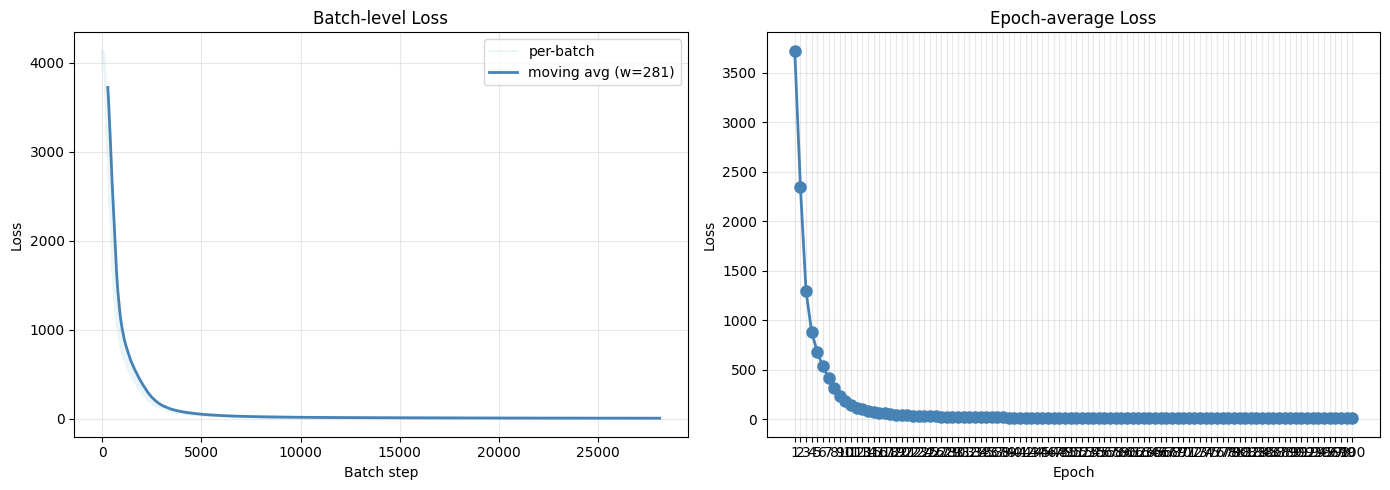

In [ ]:
# ===== 학습 실행 =====
# epoch별 평균 손실과 배치별 손실을 모두 기록해 학습 곡선을 그립니다.
import matplotlib.pyplot as plt

n = enc_train.size(0)
loss_history = []        # epoch별 평균 손실
batch_loss_history = []  # 배치별 손실 (디테일한 추세 확인용)

for ep in range(EPOCHS):
    model.train()
    idxs = list(range(0, n, BATCH))
    random.shuffle(idxs)   # 매 에폭마다 배치 순서 셔플
    total = 0.0
    pbar = tqdm(idxs, desc=f"Epoch {ep+1}/{EPOCHS}")
    for i, st in enumerate(pbar):
        s = enc_train[st:st+BATCH]
        t = dec_train[st:st+BATCH]
        loss = train_step(s, t)
        total += loss
        batch_loss_history.append(loss)
        pbar.set_postfix(loss=f"{total/(i+1):.4f}")

    epoch_loss = total / len(idxs)
    loss_history.append(epoch_loss)
    print(f"  → Epoch {ep+1} 평균 손실: {epoch_loss:.4f}")


# ===== 학습 곡선 시각화 =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 배치 단위 (이동 평균으로 스무딩)
batch_arr = np.array(batch_loss_history)
window = max(50, len(batch_arr) // 100)
smoothed = np.convolve(batch_arr, np.ones(window)/window, mode="valid")
axes[0].plot(batch_arr, alpha=0.25, color="lightblue", label="per-batch")
axes[0].plot(range(window-1, len(batch_arr)), smoothed,
             color="steelblue", linewidth=2, label=f"moving avg (w={window})")
axes[0].set_title("Batch-level Loss")
axes[0].set_xlabel("Batch step")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 오른쪽: epoch 평균
axes[1].plot(range(1, len(loss_history)+1), loss_history,
             marker="o", color="steelblue", linewidth=2, markersize=8)
axes[1].set_title("Epoch-average Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_xticks(range(1, len(loss_history)+1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ===== Greedy Decoding 추론 =====
@torch.no_grad()
def chat(question, max_len=30):
    """Transformer 챗봇 답변 생성 (greedy).

    매 스텝마다 확률이 가장 높은 토큰을 하나씩 생성.
    <end> 토큰이 나오거나 max_len에 도달하면 종료.
    """
    model.eval()
    s = preprocess_sentence(question)
    toks = mecab.morphs(s)
    ids = [word2idx.get(t, word2idx[UNK]) for t in toks]
    src = torch.tensor([ids], dtype=torch.long, device=device)
    out = torch.tensor([[word2idx[START]]], dtype=torch.long, device=device)
    for _ in range(max_len):
        enc_m, dec_self_m, cross_m = make_masks(src, out, pad_id=0)
        logits = model(src, out, enc_m, dec_self_m, cross_m)
        nxt = logits[0, -1].argmax().item()
        out = torch.cat([out, torch.tensor([[nxt]], device=device)], dim=1)
        if nxt == word2idx[END]:
            break
    # <start>는 출력에서 제외하고, 마지막 <end>가 있으면 제거
    pred = [idx2word[i] for i in out[0].tolist()[1:]]
    if pred and pred[-1] == END:
        pred = pred[:-1]
    return " ".join(pred)


# 과제 예문에 대한 답변 생성
EXAMPLES = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]
print("=== Transformer 챗봇 답변 ===")
for q in EXAMPLES:
    print(f"Q: {q}")
    print(f"A: {chat(q)}\n")


=== Transformer 챗봇 답변 ===
Q: 지루하다, 놀러가고 싶어.
A: 마음 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 충분히 아파하

Q: 오늘 일찍 일어났더니 피곤하다.
A: 마음 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 좋 은 사람 은 사람 이 에요 .

Q: 집에 있는다는 소리야.
A: 마음 이 있 어요 .



## Step 7. 성능 측정 + RAG retrieval 챗봇 비교

### 두 챗봇

| 방식 | 동작 |
|---|---|
| **Transformer (생성형)** | 학습된 모델이 토큰을 하나씩 생성 |
| **RAG (검색형)** | SBERT로 KB에서 가장 비슷한 질문을 찾아 그 답변을 반환 |

### RAG 인덱스 구성

- 학습에 사용된 (que, ans) 쌍 중 **검증셋에 포함되지 않은 것**을 KB로 사용
- 모든 KB 질문을 SBERT로 임베딩 (cosine 유사도로 검색)

### BLEU

- nltk `corpus_bleu`로 BLEU-1, -2, -3, -4 계산
- 짧은 답변에서 0이 자주 나오므로 smoothing 적용
- 검증셋의 정답(`ans_corpus[i]`)을 reference로 사용


In [ ]:
# 검증셋 분리: 원본 페어 중 일부를 BLEU 평가용으로 떼어 둠
# 동일 시드 사용 → 재현 가능
random.seed(0)
N = len(que_corpus)
indices = list(range(N))
random.shuffle(indices)
val_size = min(500, N // 10)
val_idx = set(indices[:val_size])

val_q = [que_corpus[i] for i in sorted(val_idx)]   # 토큰 리스트 (질문)
val_a = [ans_corpus[i] for i in sorted(val_idx)]   # 토큰 리스트 (정답)
print("validation size:", len(val_q))


validation size: 500


In [ ]:
# RAG 인덱스 구축: SBERT로 모든 KB 질문 임베딩
# - 학습한 Transformer 인코더 mean-pool 대신 SBERT 사용 → 검색 품질 ↑
# - 학습에 쓰인 원본(que_corpus) 중 validation에 포함되지 않은 것만 KB로 사용

kb_q_tokens, kb_a_tokens = [], []
for i, (q, a) in enumerate(zip(que_corpus, ans_corpus)):
    if i in val_idx:
        continue
    kb_q_tokens.append(q)
    kb_a_tokens.append(a)

print(f"KB size: {len(kb_q_tokens)}")

# SBERT로 KB 질문 임베딩 (정규화)
kb_texts = [" ".join(q) for q in kb_q_tokens]
kb_vecs = sbert.encode(
    kb_texts,
    convert_to_tensor=True,
    show_progress_bar=True,
    batch_size=64,
    normalize_embeddings=True,
)
print("kb_vecs:", kb_vecs.shape)


KB size: 7230


Batches:   0%|          | 0/113 [00:00<?, ?it/s]

kb_vecs: torch.Size([7230, 768])


In [ ]:
# RAG 챗봇: 가장 유사한 질문의 답변을 반환
@torch.no_grad()
def chat_rag(question_text, top_k=1):
    q_clean = preprocess_sentence(question_text)
    q_tokens_str = " ".join(mecab.morphs(q_clean))
    qv = sbert.encode(
        [q_tokens_str],
        convert_to_tensor=True,
        normalize_embeddings=True,
    )[0]
    sims = kb_vecs @ qv             # cosine (이미 정규화됨)
    top = torch.topk(sims, k=top_k)
    if top_k == 1:
        i = top.indices.item()
        return " ".join(kb_a_tokens[i])
    return [(" ".join(kb_a_tokens[i.item()]), float(s)) for i, s in zip(top.indices, top.values)]


print("=== RAG 챗봇 답변 (SBERT 기반) ===")
for q in EXAMPLES:
    print(f"Q: {q}")
    print(f"A: {chat_rag(q)}\n")


=== RAG 챗봇 답변 (SBERT 기반) ===
Q: 지루하다, 놀러가고 싶어.
A: 세상 에 는 흥미 로운 일 이 많 은 걸요 .

Q: 오늘 일찍 일어났더니 피곤하다.
A: 푹 쉬 세요 .

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 좋 은 만남 이 었 길 바랍니다 .

Q: 집에 있는다는 소리야.
A: 내 집 마련 축하 드려요 .



In [ ]:
# BLEU 점수 계산
import nltk
nltk.download("punkt", quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
smooth = SmoothingFunction().method1


def calculate_bleu(predictions, references):
    """BLEU-1 ~ BLEU-4 corpus BLEU 점수 계산.

    Parameters
    ----------
    predictions : list[list[str]]
        모델이 생성한 답변들 (토큰 리스트의 리스트)
    references : list[list[str]]
        정답 답변들 (각 샘플당 하나의 reference)

    Returns
    -------
    dict[str, float]
        {"BLEU-1": ..., "BLEU-2": ..., "BLEU-3": ..., "BLEU-4": ...}

    Notes
    -----
    - corpus_bleu는 reference를 [[ref1], [ref2], ...] 형식으로 받음
    - 짧은 답변에서 0이 자주 나오므로 smoothing method1 적용
    """
    refs = [[r] for r in references]
    scores = {}
    for n in range(1, 5):
        w = tuple([1.0 / n] * n + [0.0] * (4 - n))
        scores[f"BLEU-{n}"] = corpus_bleu(refs, predictions, weights=w, smoothing_function=smooth)
    return scores


In [ ]:
# 5) 두 챗봇에 대해 validation BLEU 측정
def predict_transformer(q_tokens):
    txt = " ".join(q_tokens)             # 이미 토큰화된 상태이므로 join해 입력
    out = chat(txt)
    return out.split()

def predict_rag(q_tokens):
    txt = " ".join(q_tokens)
    return chat_rag(txt).split()

preds_tf = [predict_transformer(q) for q in tqdm(val_q, desc="Transformer 추론")]
preds_rag = [predict_rag(q)         for q in tqdm(val_q, desc="RAG 추론")]

bleu_tf  = calculate_bleu(preds_tf,  val_a)
bleu_rag = calculate_bleu(preds_rag, val_a)

print("=== BLEU (validation) ===")
print("Transformer:", {k: f"{v:.4f}" for k, v in bleu_tf.items()})
print("RAG        :", {k: f"{v:.4f}" for k, v in bleu_rag.items()})


Transformer 추론:   0%|          | 0/500 [00:00<?, ?it/s]

RAG 추론:   0%|          | 0/500 [00:00<?, ?it/s]

=== BLEU (validation) ===
Transformer: {'BLEU-1': '0.1004', 'BLEU-2': '0.0379', 'BLEU-3': '0.0181', 'BLEU-4': '0.0093'}
RAG        : {'BLEU-1': '0.2037', 'BLEU-2': '0.0983', 'BLEU-3': '0.0577', 'BLEU-4': '0.0354'}


In [ ]:
# 6) 예문에 대해 두 챗봇 답변 나란히 비교
print("=== 예문 비교 ===")
for q in EXAMPLES:
    print(f"Q   : {q}")
    print(f"TF  : {chat(q)}")
    print(f"RAG : {chat_rag(q)}")
    print()


=== 예문 비교 ===
Q   : 지루하다, 놀러가고 싶어.
TF  : 마음 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 충분히 아파하
RAG : 세상 에 는 흥미 로운 일 이 많 은 걸요 .

Q   : 오늘 일찍 일어났더니 피곤하다.
TF  : 마음 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을 생각 을
RAG : 푹 쉬 세요 .

Q   : 간만에 여자친구랑 데이트 하기로 했어.
TF  : 좋 은 사람 은 사람 이 에요 .
RAG : 좋 은 만남 이 었 길 바랍니다 .

Q   : 집에 있는다는 소리야.
TF  : 마음 이 있 어요 .
RAG : 내 집 마련 축하 드려요 .



## 정리

### 데이터 증강 효과

| 단계 | 추가된 페어 수 (예상) | 의의 |
|---|---|---|
| 원본 | ~11,000 | 기본 |
| + 단순 EDA | ~10,000 | 표현 변동에 강건 |
| + SBERT 유사 질문 매칭 | ~10,000 | 같은 의미 다양한 표현 학습 |
| + Back-Translation | ~3,000 | 자연스러운 표현 다양화 |
| **합계** | **~34,000** | **원본 3배** |

### Transformer vs RAG

- **Transformer 챗봇**: 학습 데이터를 일반화해 새 답변 생성 가능. 데이터가 1만 개 수준이라 답이 짧거나 어색해질 수 있음.
- **RAG 챗봇**: SBERT가 사전 학습된 강력한 임베딩이라 즉시 사용 가능. KB에 비슷한 질문이 있으면 자연스러운 답변. KB를 벗어난 질문에는 약함.

BLEU만 보면 RAG가 더 높게 나오는 경향이 있지만(검증 정답이 KB와 동일/유사할 수 있어서), **새로운 질문 표현에 대한 일반화는 Transformer가 유리**합니다.

### 하이퍼파라미터 튜닝 포인트

- `EPOCHS`, `BATCH`, `WARMUP` — 학습량과 안정성
- `HP["n_layers"]`, `HP["d_model"]`, `HP["dropout"]` — 모델 용량과 과적합 방지
- 증강 셀의 `sim_threshold`, `MAX_BT_SAMPLES`, `p_delete/p_swap` — 증강 강도
- `chat()`의 greedy → beam search로 바꾸면 답변 품질 향상 (구현 필요)
